# Lectura de tonos en un telefono de linea
123
456
789
*0#

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

In [91]:
# Busca los 5 mayores valores dentro de todas las magnitudes y retorna la frecuencia y magnitud de dichos picos
def busca_picos(magnitudes, frecuencias): #magnitud dbV
    # Se encuentran los picos y se los ordena en bajo y alto
    picos, _ = find_peaks(magnitudes, distance=10)
    picos = picos[np.argsort(magnitudes[picos])[::-1]]

    tonos = picos[:2] #Los 2 mayores (tonos)
    tonos_sorted = sorted(tonos, key=lambda i: frecuencias[i]) # Ordeno por frecuencia

    armonicos = picos[2:4] #Los terceros y cuartos mayores (armonicos)
    armonicos_sorted = sorted(armonicos, key=lambda i: frecuencias[i])

    espuria = picos[4] #Quinto mayor (espuria)

    picos_interes = tonos_sorted + armonicos_sorted + [espuria]

    return {
        "picos": picos_interes, #indices en el arr magnitud y frecuencia
        # Valores explicitos de la frecuencia y magnitud de cada pico
        "tono_bajo": {"frecuencia": frecuencias[tonos_sorted[0]], "magnitud": magnitudes[tonos_sorted[0]]},
        "tono_alto": {"frecuencia": frecuencias[tonos_sorted[1]], "magnitud": magnitudes[tonos_sorted[1]]},
        "armonico_bajo": {"frecuencia": frecuencias[armonicos_sorted[0]], "magnitud": magnitudes[armonicos_sorted[0]]},
        "armonico_alto": {"frecuencia": frecuencias[armonicos_sorted[1]], "magnitud": magnitudes[armonicos_sorted[1]]},
        "espuria": {"frecuencia": frecuencias[espuria], "magnitud": magnitudes[espuria]}
    }

# Calcula el piso de ruido como la mediana de magnitudes ignorando picos de las señal
def piso_ruido(magnitud_db, picos):
    picos = picos[:4] # Remuevo la espuria para que no se la ignore en el calculo
    # Piso de ruido (mediana de la FFT excluyendo los dos tonos y valores cercanos)
    mascara = np.ones(len(magnitud_db), dtype=bool)
    # Para el calculo de piso de ruido ignoro valores cercanos a los picos
    for indice in picos:
        ini = max(0, indice - 5)
        fin = min(len(magnitud_db), indice + 6)
        mascara[ini:fin] = False

    piso_ruido_db = np.median(magnitud_db[mascara])
    return piso_ruido_db

In [92]:
def procesar_mediciones(archivos, dt=1.00000e-04):
    # dt es igual para todas las medidas
    N = None
    potencias = [] #arr para guardar las potencias de las fft de cada archivo

    tiempo = None
    voltaje = None

    for i, archivo in enumerate(archivos):

        df = pd.read_csv(archivo,
            skiprows=16, # Saltea informacion sobre el muestreo
            names=['Tiempo', 'Voltaje'],index_col=False)

        if N is None:
            N = len(df)

        # Guardo la primera señal para graficar en tiempo
        if i == 0:
            tiempo = df["Tiempo"].to_numpy()
            voltaje = df["Voltaje"].to_numpy()

        signal = df["Voltaje"].to_numpy()

        # FFT
        fft_valores = fft(signal)
        mitad = N // 2
        magnitud = (2.0 / N) * np.abs(fft_valores[:mitad])

        # f=0 que no tiene componente "negativa" por la cual ser duplicada
        magnitud[0] = magnitud[0]/2 #DC
        if N % 2 == 0:
            magnitud[-1] /= 2 # Nyquist (por redondeo al dividir la ultima frecuencia del array tampoco debe ser duplicada)
            
        # Potencia
        potencias.append(magnitud**2) # Pot = Mag^2
    
# Frecuencias
    frecuencias = fftfreq(N, dt)[:mitad]

    # Promedio RMS
    potencia_promedio = np.mean(potencias, axis=0)
    magnitud_promedio = np.sqrt(potencia_promedio)

# MAGNITUDES
    # dBV
    magnitud_rms = magnitud_promedio / np.sqrt(2)
    magnitud_dbv = 20 * np.log10(np.clip(magnitud_rms, 1e-5, None))
    
    #dBm
    R = 600 # Impedancia de entrada de 600ohms
    magnitud_dbm = 20*np.log10(np.clip(magnitud_rms,1e-12,None))-10*np.log10(R)+30

#############
# Para usar dBV o dBm tambien cambiarlo en el bloque codigo principal
# al utilizar graficar_fft()
#############
# Picos y piso ruido (dbm)
    picos = busca_picos(magnitud_dbm, frecuencias)
    piso_ruido_db = piso_ruido(magnitud_dbm, picos["picos"])
# Picos y piso ruido (dbV)
    #picos = busca_picos(magnitud_dbv, frecuencias)
    #piso_ruido_db = piso_ruido(magnitud_dbv, picos["picos"])


    return {
        "tiempo": tiempo,
        "voltaje": voltaje,
        "frecuencia": frecuencias,
        "magnitud": magnitud_promedio,
        "magnitud_dbv": magnitud_dbv,
        "magnitud_dbm": magnitud_dbm,
        "picos": picos,
        "piso_ruido_db": piso_ruido_db,
        "N": N
    }

Grafica la FFT con las coordenadas de los 2 picos maximos y el piso de ruido

In [93]:
def graficar_fft(frecuencias, magnitud, picos, piso_ruido, titulo, ax):

    ax.plot(frecuencias,magnitud,color="red",linewidth=1.2)

    ax.axhline( # Linea del piso de ruino
        piso_ruido,
        color="blue",
        linestyle="--",
        linewidth=1
    )

    ax.text( # Leyenda del piso de ruido
        0.98,
        0.03,
        f"Ruido: {piso_ruido:.1f} dB",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    for indice in picos:
        freq = frecuencias[indice]
        amp = magnitud[indice]

        ax.scatter(freq, amp, s=25, color="blue")

        ax.annotate(
            f"{freq:.0f} Hz\n{amp:.1f} dB",
            (freq, amp),
            textcoords="offset points",
            xytext=(6,-6), # Distancia del texto al punto
            fontsize=12,
            bbox=dict(
                facecolor="gray", # Color de fondo (caja)
                alpha=0.3, # Transparencia
                edgecolor="none"
            )
        )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.set_xlim(0, 2000)
    ax.grid(True, alpha=0.4)

## Codigo principal
Esta seccion declara las teclas y tonos nominales, y llama a las funciones de fft y graficos en ciclo para leer todos los archivos, procesarlos, promediarlos y graficarlos. Guarda los resultados para graficar o expresarlos en una tabla.

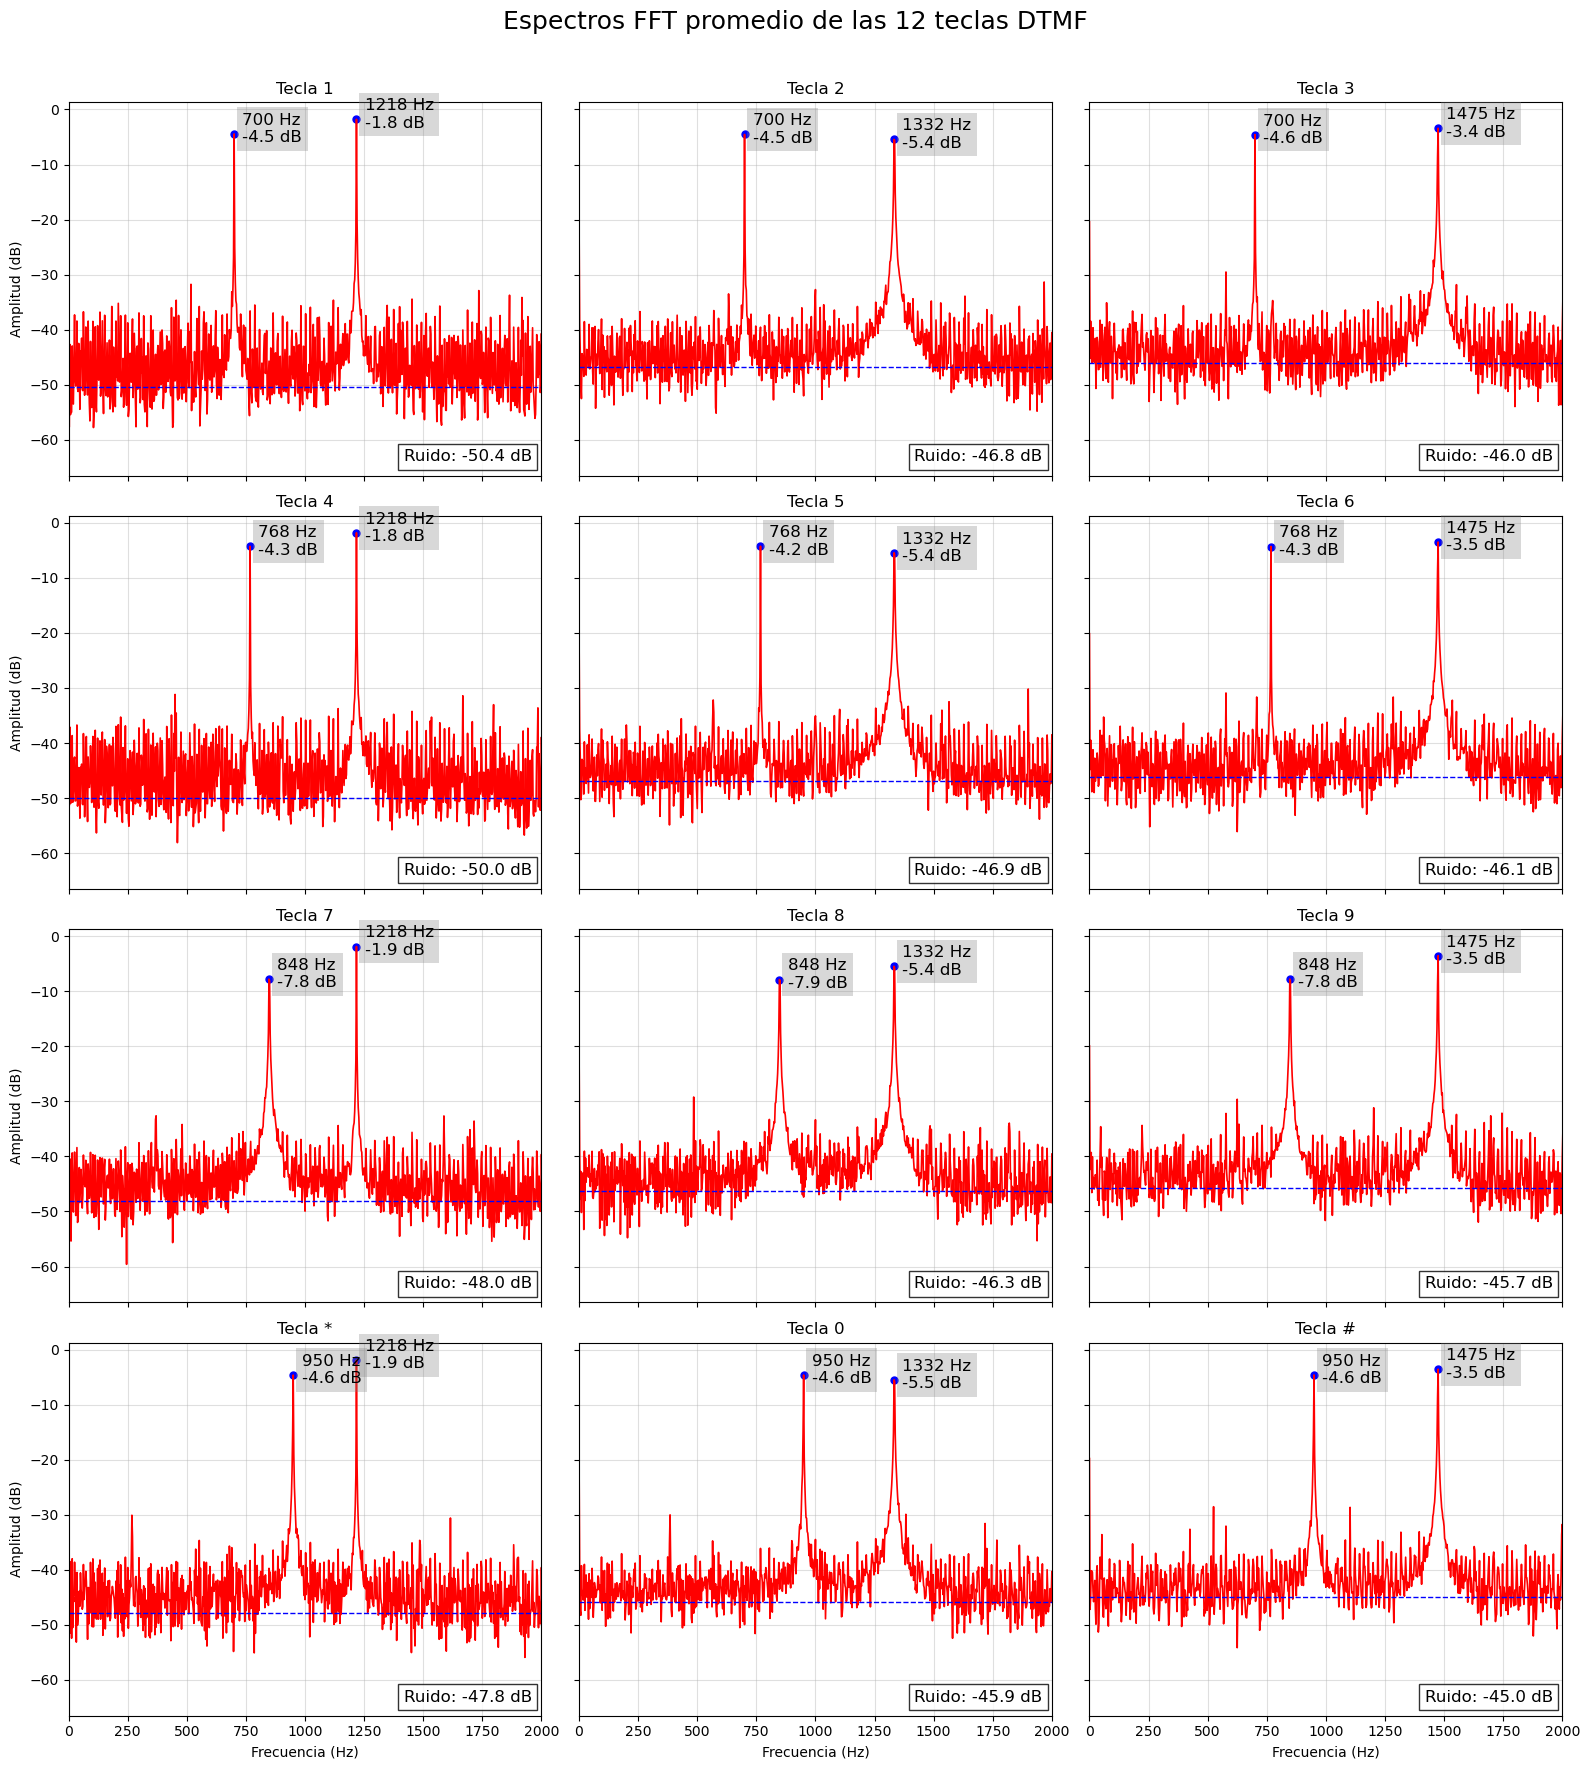

In [94]:
tono_columna = [1209, 1336, 1447]
tono_fila = [697, 770, 852, 941]

teclas = [
    ['1', '2', '3'],
    ['4', '5', '6'],
    ['7', '8', '9'],
    ['*', '0', '#']
]

tabla_tonos_hz = []
resumen_db = []

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
    sharex=True,
    sharey=True
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [ # Carga los archivos de a tandas de 5 mediciones
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5

        res = procesar_mediciones(archivos)
        
        tonos_detectados = res["picos"]["picos"][:2]
        #par de tonos que se esperan por la fila y columna de la tecla
        tonos_esperados = np.sort([tono_fila[fila],tono_columna[columna]])


        tabla_tonos_hz.append([
            tecla,
            tonos_esperados[0],
            res["picos"]["tono_bajo"]["frecuencia"],
            tonos_esperados[1],
            res["picos"]["tono_alto"]["frecuencia"],
        ])
        resumen_db.append([
            tecla,
            res["picos"], #aca van los tonos, armonicos y espuria (frecuencia y magnitud)
            res["piso_ruido_db"],
        ])

#############
# Para usar dBV o dBm tambien cambiarlo en picos y piso de ruido
# en procesar_mediciones()
#############
        graficar_fft(res["frecuencia"], 
                res["magnitud_dbm"], 
                #res["magnitud_dbv"], 
                tonos_detectados, res["piso_ruido_db"], 
                tecla, axs[fila, columna])

# Etiquetas solo en los bordes
for ax in axs[-1, :]:
    ax.set_xlabel("Frecuencia (Hz)")

for ax in axs[:, 0]:
    ax.set_ylabel("Amplitud (dB)")

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Analisis de todo el espectro

En altas frecuencias, para todas las señales, aparecen 2 picos. Estos, aunque estrictamente pueden considerarse espurias, son armonicos. En realidad para el analisis conviene ignorar estas 2 "espurias" y tomar la tercera mayor, es decir, la verdadera espuria.
Ademas hay un analisis de PSD (densidad espectral de potencia) para verificar que el piso de ruido tenga sentido (me daba la sensacion de que estaba dando muy bajo, pero esta bien)

<Figure size 640x480 with 0 Axes>

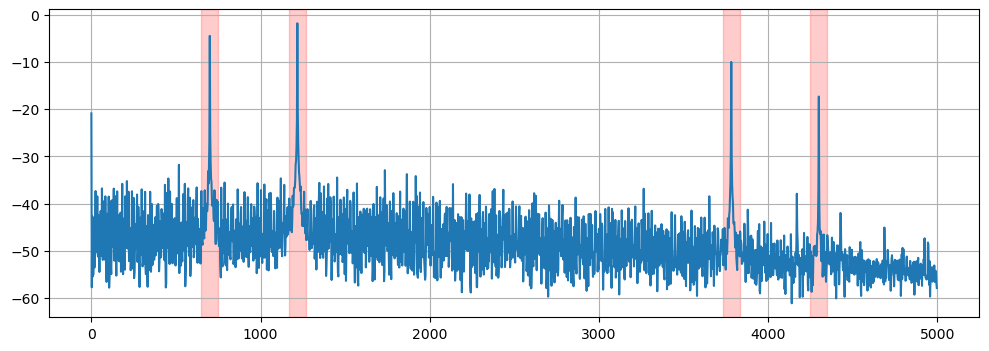

In [95]:
archivos = [
    f"medidas/DS{0+i:04d}.CSV"
    for i in range(5)
]

resultado = procesar_mediciones(archivos)

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)
top_4 = resultado["picos"]["picos"][:4]

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

plt.figure(figsize=(12,4))
plt.plot(resultado["frecuencia"], resultado["magnitud_dbm"])

for indice in top_4:
    plt.axvspan(
        resultado["frecuencia"][max(0, indice-20)],
        resultado["frecuencia"][min(len(resultado["frecuencia"])-1, indice+20)],
        color="red",
        alpha=0.2
    )
plt.grid(True)

### Graficos en tiempo

Con el parametro division se deja como esta o reduce el eje en tiempo. La idea es capturar el efecto de alias (segun el profesor). Jugando con este parametro de division se deberia mejorar la visualizacion del alias

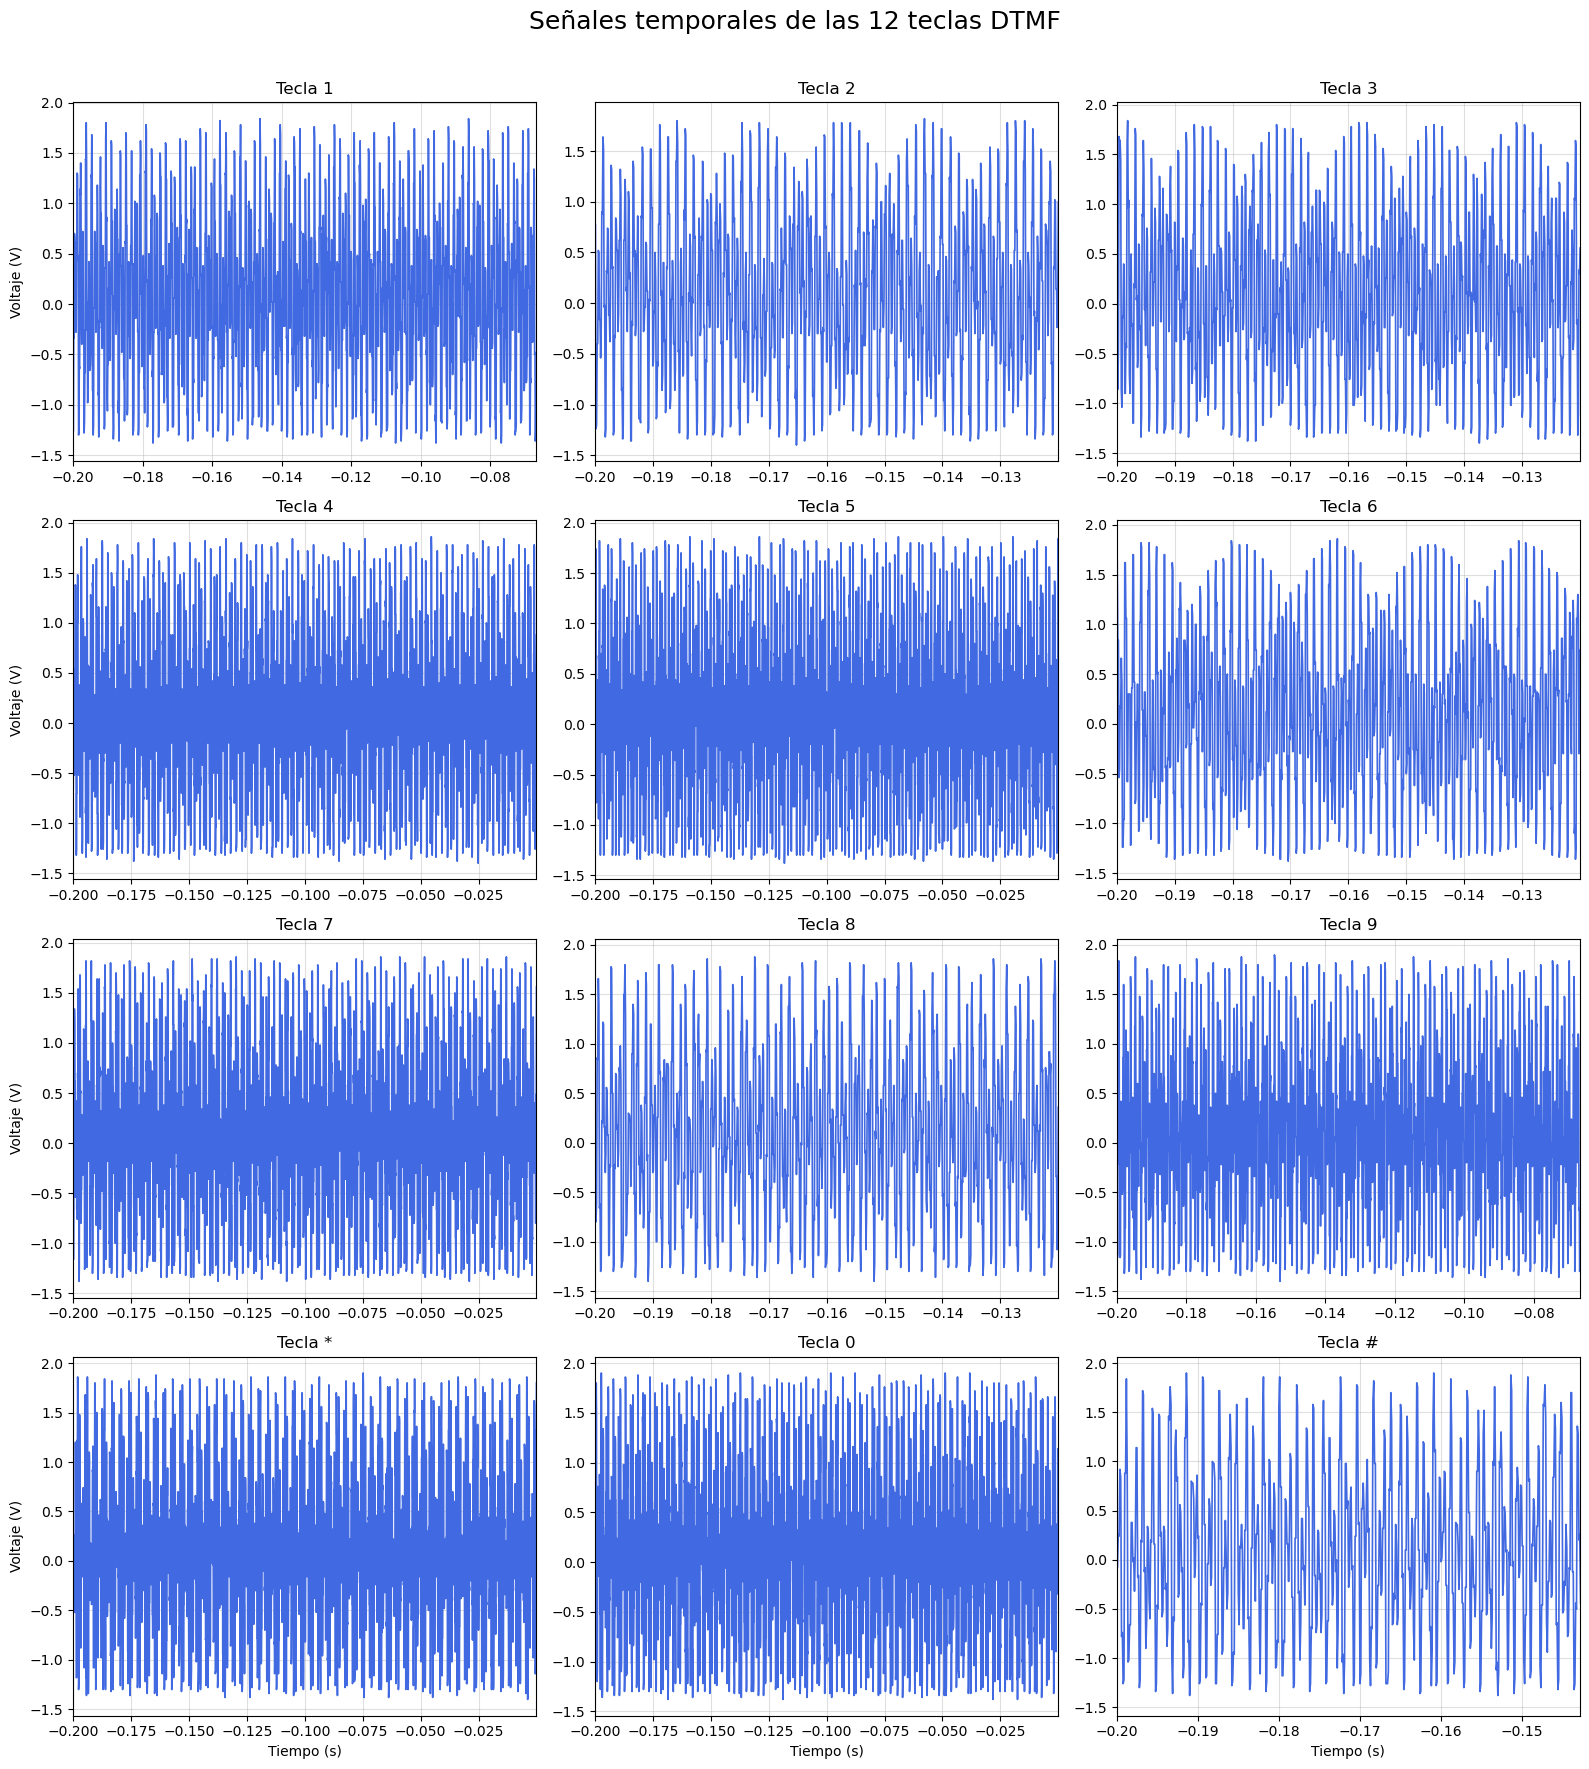

In [96]:
def graficar_senal(resultado, titulo, ax, division):

    tiempo = resultado["tiempo"]
    voltaje = resultado["voltaje"]

    ax.plot(
        tiempo,
        voltaje,
        color="royalblue",
        linewidth=1.2
    )

    # Mostrar sólo una pequeña porción para apreciar la forma de onda
    ax.set_xlim(
        tiempo[0],
        tiempo[0] + (tiempo[-1] - tiempo[0]) / division
    )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.grid(True, alpha=0.4)

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5
        division = 2
        if tecla == '1' or tecla == '9':
            division = 3
        elif tecla == '#':
            division = 7
        elif tecla == '2' or tecla == '3' or tecla == '6' or tecla == '8':
            division = 5

        #print(f"Tecla {tecla}: división = {division}")
        resultado = procesar_mediciones(archivos)

        graficar_senal(
            resultado,
            tecla,
            axs[fila, columna],
            division
        )

for ax in axs[-1, :]:
    ax.set_xlabel("Tiempo (s)")

for ax in axs[:, 0]:
    ax.set_ylabel("Voltaje (V)")

fig.suptitle(
    "Señales temporales de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Tablas

Para pasarlas al docs encontre que es mas facil copiarlo de aca, pegarlo en bloc de notas, y ahi pegarlo en excel. Hay algo en el formato que se pierde al pegarlo en bloc de notas y entonces excel no se pone mal.

### Tabla de frecuencias

In [97]:
tabla = []

for tecla, esp1, det1, esp2, det2 in tabla_tonos_hz:

    err1 = 100 * abs(det1 - esp1) / esp1
    err2 = 100 * abs(det2 - esp2) / esp2

    tabla.append([
        tecla,
        esp1,
        round(det1, 1),
        round(err1, 2),
        esp2,
        round(det2, 1),
        round(err2, 2)
    ])

df_resumen = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Esp. Bajo",
        "Det. Bajo",
        "Error (%)",
        "Esp. Alto",
        "Det. Alto",
        "Error (%)"
    ]
)

print(df_resumen)

   Tecla  Esp. Bajo  Det. Bajo  Error (%)  Esp. Alto  Det. Alto  Error (%)
0      1        697      700.0       0.43       1209     1217.5       0.70
1      2        697      700.0       0.43       1336     1332.5       0.26
2      3        697      700.0       0.43       1447     1475.0       1.94
3      4        770      767.5       0.32       1209     1217.5       0.70
4      5        770      767.5       0.32       1336     1332.5       0.26
5      6        770      767.5       0.32       1447     1475.0       1.94
6      7        852      847.5       0.53       1209     1217.5       0.70
7      8        852      847.5       0.53       1336     1332.5       0.26
8      9        852      847.5       0.53       1447     1475.0       1.94
9      *        941      950.0       0.96       1209     1217.5       0.70
10     0        941      950.0       0.96       1336     1332.5       0.26
11     #        941      950.0       0.96       1447     1475.0       1.94


### Tabla de dB

In [98]:
tabla = []

for tecla, picos, piso_ruido in resumen_db:

    tono_bajo_db = picos["tono_bajo"]["magnitud"]
    tono_alto_db = picos["tono_alto"]["magnitud"]
    espuria_db = picos["espuria"]["magnitud"]

    tabla.append([
        tecla,
        round(tono_bajo_db, 2),
        round(tono_alto_db, 2),
        round(piso_ruido, 2),
        round(tono_alto_db - tono_bajo_db, 2),
        round(espuria_db - tono_bajo_db, 2)
        # Falta obtener la espuria posta, que seria el quinto mayor pico de la FFT 
        # El primero y segundo mayor: los dos tonos
        # tercer y cuarto mayor: los armonicos (espurias "falsas")
        # Quinto mayor : la espuria posta que nos interesa tener para el analisis
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (dB)",
        "Tono alto (dB)",
        "Piso de ruido (dB)",
        "Preenfasis (dB)",
        "Espuria (dB)",
    ]
)

print(df_db)

   Tecla  Tono bajo (dB)  Tono alto (dB)  Piso de ruido (dB)  Preenfasis (dB)  \
0      1           -4.45           -1.79              -50.41             2.67   
1      2           -4.55           -5.44              -46.83            -0.90   
2      3           -4.57           -3.42              -46.03             1.15   
3      4           -4.27           -1.82              -50.05             2.45   
4      5           -4.25           -5.44              -46.88            -1.19   
5      6           -4.30           -3.49              -46.09             0.81   
6      7           -7.79           -1.87              -48.01             5.92   
7      8           -7.86           -5.45              -46.34             2.41   
8      9           -7.78           -3.54              -45.73             4.23   
9      *           -4.62           -1.91              -47.83             2.71   
10     0           -4.61           -5.48              -45.90            -0.88   
11     #           -4.60    

### Tabla picos "espurias" falsos que en realidad corresponden a armonicos

In [99]:
tabla = []

for tecla, picos, piso_ruido in resumen_db:

    tono_bajo_db = picos["tono_bajo"]["frecuencia"]
    tono_alto_db = picos["tono_alto"]["frecuencia"]
    espuria_db = picos["armonico_bajo"]["frecuencia"]

    tabla.append([
        tecla,
        round(picos["tono_bajo"]["frecuencia"], 2),
        round(picos["tono_alto"]["frecuencia"], 2),
        round(picos["armonico_bajo"]["frecuencia"], 2),
        round(picos["armonico_alto"]["frecuencia"], 2)
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (hz)",
        "Tono alto (hz)",
        "Armonico bajo (hz)",
        "Armonico alto (hz)"
    ]
)

print(df_db)

   Tecla  Tono bajo (hz)  Tono alto (hz)  Armonico bajo (hz)  \
0      1           700.0          1217.5              3782.5   
1      2           700.0          1332.5              3667.5   
2      3           700.0          1475.0              3525.0   
3      4           767.5          1217.5              3782.5   
4      5           767.5          1332.5              3667.5   
5      6           767.5          1475.0              3525.0   
6      7           847.5          1217.5              3782.5   
7      8           847.5          1332.5              3667.5   
8      9           847.5          1475.0              3525.0   
9      *           950.0          1217.5              3782.5   
10     0           950.0          1332.5              3667.5   
11     #           950.0          1475.0              3525.0   

    Armonico alto (hz)  
0               4300.0  
1               4300.0  
2               4300.0  
3               4232.5  
4               4232.5  
5               4

## Test
Verifico calculo de magnitud dBV

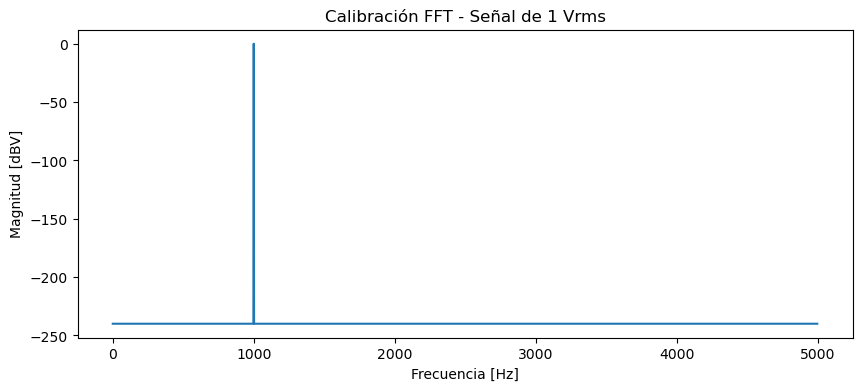

In [106]:
def procesar_medicion_test(dt=1e-4):

    # Parámetros
    N = 4000
    Fs = 1/dt

    # Señal de prueba
    Vrms = 1                      # 1 Vrms
    Vp = Vrms * np.sqrt(2)        # amplitud pico

    f = 1000                      # Hz (menor que Fs/2)

    tiempo = np.arange(N) * dt
    voltaje = Vp * np.sin(2*np.pi*f*tiempo)

    # FFT
    fft_valores = fft(voltaje)
    mitad = N // 2

    magnitud = (2.0 / N) * np.abs(fft_valores[:mitad])

    # Corrección DC y Nyquist
    magnitud[0] /= 2
    if N % 2 == 0:
        magnitud[-1] /= 2

    # Frecuencias
    frecuencias = fftfreq(N, dt)[:mitad]

    # Conversión a RMS
    magnitud_rms = magnitud / np.sqrt(2)

    # dBV
    magnitud_dbv = 20*np.log10(np.clip(magnitud_rms, 1e-12, None))

    # dBm (600 ohm)
    R = 600
    magnitud_dbm = (
        20*np.log10(np.clip(magnitud_rms, 1e-12, None))
        - 10*np.log10(R)
        + 30
    )

    # Buscar picos (para la prueba usar dBV)
    #picos = busca_picos(magnitud_dbv, frecuencias)
    #piso_ruido_db = piso_ruido(magnitud_dbv, picos["picos"])

    return {
        "tiempo": tiempo,
        "voltaje": voltaje,
        "frecuencia": frecuencias,
        "magnitud": magnitud,
        "magnitud_dbv": magnitud_dbv,
        "magnitud_dbm": magnitud_dbm,
        "N": N
    }


# ===========================
# Ejecutar prueba de calibración
# ===========================

res = procesar_medicion_test()
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(res["frecuencia"], res["magnitud_dbv"])
#ax.plot(frecuencia_pico, nivel_pico, "ro")

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud [dBV]")
ax.set_title("Calibración FFT - Señal de 1 Vrms")

plt.show()